# 01 — Long the bounce: честное распределение LONG-стороны

iter00 показал: после дампа цена отскакивает вверх → правильная сторона **LONG**.
Здесь меряем лонг честно (как pump 06_ladder_vs_stop): распределение, win%, q10,
mean/std, подбор стопа, MAE (насколько глубоко проседало до отскока = риск-хвост).

**Сетап (honest):**
- Триггеры −5% и −7% за 15м (−1% выброшен — мёртвая зона).
- Вход **следующим баром** (i+1), lookahead-free first-trigger (как iter00).
- Полный поминутный путь после входа → симуляция стопа + выход по горизонту.
- Стоп по **close** (оговорка: внутрибарный low мог бы задеть раньше → оптимистично).
- Кости: 0.15% round-trip в net. Baseline = случайная минута.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np
from pathlib import Path
OUT=Path("_out")
z=np.load(OUT/"closes_2024.npz", allow_pickle=True)
closes={k:z[k] for k in z.files}
SYMS=list(closes.keys())
print("symbols:", len(SYMS))

WIN=15; MAXH=240; THRESH=[0.05,0.07]
def first_triggers(c,thr):
    if len(c)<WIN+MAXH+3: return np.array([],dtype=int)
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=r<=-thr; fire=cond.copy(); fire[1:]&=~cond[:-1]
    idx=np.where(fire)[0]
    idx=idx[(idx>=WIN)&(idx+1+MAXH<len(c))]   # entry at i+1, need i+1+MAXH
    return idx

symbols: 50


In [2]:
# Full forward path per event, relative to ENTRY = close[i+1]
def path_matrix(thr):
    rows=[]
    for s in SYMS:
        c=closes[s]
        for i in first_triggers(c,thr):
            e=c[i+1]
            rows.append(c[i+1:i+1+MAXH+1]/e-1)   # t=0..MAXH (t0 ~ 0)
    return np.array(rows)
P={thr:path_matrix(thr) for thr in THRESH}
for thr in THRESH: print(f"-{int(thr*100)}%: n={len(P[thr])}, path len={P[thr].shape[1]}")

-5%: n=2517, path len=241
-7%: n=1182, path len=241


In [3]:
# LONG PnL helpers. path[:,t] = cumulative return since entry (long PnL before costs)
COST=0.0015
def stats(a):
    return dict(n=len(a),mean=a.mean(),median=np.median(a),win=(a>0).mean(),
                std=a.std(),q10=np.quantile(a,.10),q90=np.quantile(a,.90),
                ms=a.mean()/a.std() if a.std()>0 else np.nan)

def long_nostop(thr,H):
    return P[thr][:,H]

def long_stop(thr,stop,H):
    # close-based stop: first minute path<=-stop -> exit at -stop, else path[H]
    pm=P[thr][:,:H+1]
    hit=pm<=-stop
    out=np.empty(len(pm))
    for k in range(len(pm)):
        w=np.where(hit[k])[0]
        out[k]=-stop if len(w) else pm[k,H]
    return out

def line(tag,a,net=True):
    s=stats(a); m=s['mean']-(COST if net else 0)
    print(f"  {tag:24} mean {m*100:+6.2f}  med {s['median']*100:+6.2f}  "
          f"win {s['win']*100:4.1f}%  q10 {s['q10']*100:+6.2f}  q90 {s['q90']*100:+6.2f}  m/std {s['ms']:+.3f}")

In [4]:
print("=== LONG PnL, NET of 0.15% round-trip (entry i+1) ===")
for thr in THRESH:
    print(f"\n-{int(thr*100)}%/15m  n={len(P[thr])}")
    for H in [60,120,240]:
        line(f"no-stop  H={H}m", long_nostop(thr,H))
    print("  --- with stop, exit H=240m ---")
    for st in [0.02,0.03,0.05]:
        line(f"stop {int(st*100)}%  H=240m", long_stop(thr,st,240))

=== LONG PnL, NET of 0.15% round-trip (entry i+1) ===

-5%/15m  n=2517
  no-stop  H=60m           mean  +0.80  med  +0.69  win 58.0%  q10  -4.65  q90  +6.96  m/std +0.200
  no-stop  H=120m          mean  +1.24  med  +1.35  win 61.0%  q10  -5.23  q90  +8.09  m/std +0.252
  no-stop  H=240m          mean  +1.48  med  +1.48  win 60.1%  q10  -5.60  q90  +9.11  m/std +0.256
  --- with stop, exit H=240m ---
  stop 2%  H=240m          mean  +0.87  med  -2.00  win 37.5%  q10  -2.00  q90  +7.22  m/std +0.206
  stop 3%  H=240m          mean  +0.78  med  -2.58  win 44.2%  q10  -3.00  q90  +7.55  m/std +0.173
  stop 5%  H=240m          mean  +0.63  med  +0.06  win 50.3%  q10  -5.00  q90  +8.43  m/std +0.128

-7%/15m  n=1182
  no-stop  H=60m           mean  +1.73  med  +1.48  win 62.7%  q10  -4.77  q90  +8.89  m/std +0.334
  no-stop  H=120m          mean  +2.47  med  +2.62  win 67.2%  q10  -5.03  q90  +9.92  m/std +0.428
  no-stop  H=240m          mean  +3.60  med  +3.65  win 67.5%  q10  -4.84  q90 

In [5]:
# MAE = max adverse excursion = deepest drawdown before exit (the risk tail)
print("=== MAE (worst drawdown within 240m after entry) ===")
for thr in THRESH:
    mae=P[thr][:,:241].min(axis=1)
    print(f"-{int(thr*100)}%  median {np.median(mae)*100:+.2f}  q10 {np.quantile(mae,.10)*100:+.2f}  "
          f"q25 {np.quantile(mae,.25)*100:+.2f}  frac< -3% = {(mae<-0.03).mean()*100:.1f}%  < -5% = {(mae<-0.05).mean()*100:.1f}%")

=== MAE (worst drawdown within 240m after entry) ===
-5%  median -2.98  q10 -13.69  q25 -7.55  frac< -3% = 49.9%  < -5% = 36.2%
-7%  median -3.07  q10 -14.07  q25 -7.09  frac< -3% = 50.3%  < -5% = 37.3%


In [6]:
# baseline long (random minute, same horizons)
rng=np.random.default_rng(1)
base=[]
for s in SYMS:
    c=closes[s]; lo,hi=WIN,len(c)-MAXH-2
    if hi<=lo: continue
    for i in rng.integers(lo,hi,size=min(300,hi-lo)):
        e=c[i+1]; base.append([c[i+1+H]/e-1 for H in [60,120,240]])
base=np.array(base)
print("=== BASELINE long (random minute), NET ===")
for j,H in enumerate([60,120,240]):
    line(f"H={H}m", base[:,j])

=== BASELINE long (random minute), NET ===
  H=60m                    mean  -0.14  med  +0.00  win 49.9%  q10  -1.20  q90  +1.22  m/std +0.010
  H=120m                   mean  -0.12  med  +0.01  win 50.2%  q10  -1.66  q90  +1.70  m/std +0.016
  H=240m                   mean  -0.12  med  -0.02  win 49.1%  q10  -2.39  q90  +2.43  m/std +0.010


[saved] notebooks\dump\_out\01_long_dist.png

WindowsPath('C:/projects/researchlab/notebooks/dump/_out/01_long_dist.png')

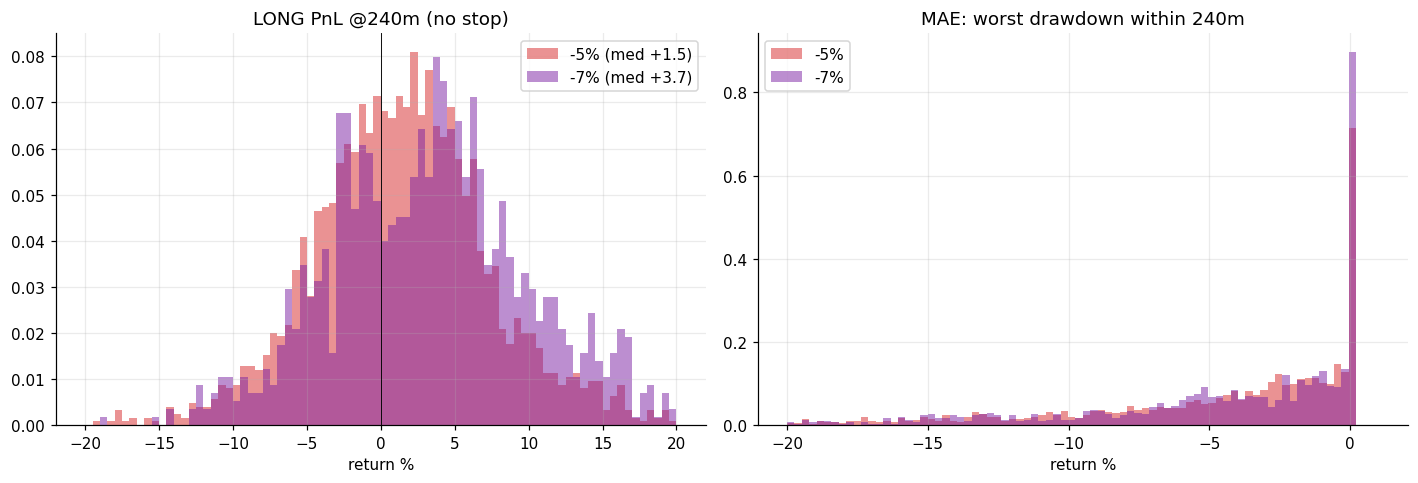

In [7]:
# distribution plots: long PnL @240 no-stop, and MAE
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
for thr,col in [(0.05,"#d62728"),(0.07,"#7b1fa2")]:
    a=long_nostop(thr,240)*100
    ax[0].hist(a,bins=80,range=(-20,20),alpha=.5,color=col,density=True,label=f"-{int(thr*100)}% (med {np.median(a):+.1f})")
    mae=P[thr][:,:241].min(axis=1)*100
    ax[1].hist(mae,bins=80,range=(-20,1),alpha=.5,color=col,density=True,label=f"-{int(thr*100)}%")
ax[0].axvline(0,color="k",lw=.6); ax[0].set_title("LONG PnL @240m (no stop)"); ax[0].set_xlabel("return %"); ax[0].legend()
ax[1].set_title("MAE: worst drawdown within 240m"); ax[1].set_xlabel("return %"); ax[1].legend()
show("01_long_dist")

## Как читать
- **Левый график** — распределение лонг-PnL на выходе 240м (без стопа). Хвост
  влево = дампы, которые продолжили падать (наш риск). Хочется положительную
  медиану и не слишком толстый левый хвост.
- **Правый** — MAE: насколько глубоко позиция проседала до отскока. Это
  напрямую говорит, какой стоп нужен, чтобы не выбивало на нормальном шуме.
- **Таблица:** сравни no-stop vs стопы (как в pump — стоп режет хвост, но может
  резать и edge), всё net костов, против baseline. Решает mean/std + q10.

*Verdict после прогона.*

## VERDICT (iter 01)

**LONG отскок прибылен и силён.** Net, вход +1 бар, выход 240м, без стопа:
−5%/15m mean +1.48% (win 60%, m/std 0.256); −7%/15m mean +3.60% (win 67%,
**m/std 0.510** — лучше лучшего pump-сетапа). Baseline −0.12%. Зеркало сошлось:
long gross ≈ −(short) из iter00.

**Стоп ВРЕДИТ (зеркало pump).** Любой стоп режет и mean, и mean/std. Причина —
MAE: медиана просадки до отскока −3%, у 50% сделок дип глубже −3%. Отскок
приходит ПОСЛЕ глубокого провала → узкий стоп выбивает перед разворотом.
Асимметрия: fade-шорт ловит редкий толстый хвост (стоп помогает); catch-the-knife
лонг терпит обычный дип (стоп вредит). Лучший риск-скор = БЕЗ стопа / очень широкий.

**КРИТИЧЕСКАЯ оговорка — survivorship bias теперь ПРОТИВ нас.** Монеты, что
дампнули и не отскочили (умерли/делистнуты), выпали из данных → лонг-edge,
вероятно, ЗАВЫШЕН. Главный скептик-чек на будущее.

**Дальше:** (1) OOS 2025/26 — держится ли; (2) survivorship — посмотреть, нет ли
выживальческого перекоса; (3) полная вселенная 165; (4) проверка якоря (first-trigger
не оракул ли). Стоп — отложить, без него лучше.